# Shared experiment workflow

**Run cells from top to bottom.** Change only the **STANDARD EXPERIMENT CONTROL** cell for the experiment name and feature additions/removals. Model-specific hyperparameters are adjustable through `MODEL_PARAM_OVERRIDES` (classical models)

**Suggested sequence:** baseline → remove one feature → add one justified feature → tune parameters → document best validation setting → evaluate final held-out test. Every run exports an experiment record; change `EXPERIMENT_ID` each time.


In [14]:
# STANDARD EXPERIMENT CONTROL — edit only this cell for normal experiments
EXPERIMENT_ID = "remove_month_v1"  # e.g. remove_month_v1, split_30pct_v1
REMOVE_FEATURES = ["month"]    # e.g. ["month"] — use actual predictor column names
TEST_SIZE = 0.20               # 0.20=80/20, 0.30=70/30, 0.10=90/10
RANDOM_STATE = 42              # fixed seed makes group splits reproducible

#Example of Model param overrides.
# "Gradient Boosting": {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 4, "subsample": 0.8},
# "HistGradientBoosting": {"max_iter": 300, "max_leaf_nodes": 20, "l2_regularization": 0.1},
# "Multiple Linear Regression": {"fit_intercept": False},
MODEL_PARAM_OVERRIDES = {}
assert 0 < TEST_SIZE < 1, "TEST_SIZE must be between 0 and 1"


# Rain Classification — Visualise, Split, Train & Save
Daily classes: <1 No/Minimal, 1–<10 Low, 10–<100 Moderate, ≥100 High.


In [15]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, joblib
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,ConfusionMatrixDisplay
R=Path.cwd(); R=R if R.name.lower()=="rain" else (R/"Rain" if (R/"Rain").exists() else R.parent/"Rain")
D=R/"dataset"/"rain_preprocessed.csv"; M=R/"trained_models"; M.mkdir(exist_ok=True)
F=["temperature_2m_max",
   "temperature_2m_min",
   "relative_humidity_2m_mean",
   "dew_point_2m_mean",
   "cloud_cover_mean",
   "pressure_msl_mean",
   "wind_speed_10m_max",
   "shortwave_radiation_sum",
   "month"]
T="rain_class"; C=["No/Minimal Rain","Low","Moderate","High"]

F = [c for c in F if c not in REMOVE_FEATURES] 
print("Experiment features:", F)
df=pd.read_csv(D); df["date"]=pd.to_datetime(df.date)
print(df.shape,df.date.min(),df.date.max()); display(df.head()); display(df[F+["rain_sum",T]].isna().sum().to_frame("missing"))


Experiment features: ['temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'dew_point_2m_mean', 'cloud_cover_mean', 'pressure_msl_mean', 'wind_speed_10m_max', 'shortwave_radiation_sum']
(458679, 15) 2021-01-01 00:00:00 2026-01-31 00:00:00


,date,prefecture,town,location_id,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,shortwave_radiation_sum,month,rain_sum,rain_class
0,2021-01-01,Aichi,Nagoya,0,5.2,-3.2,76.0,-2.1,49.0,1019.3,25.1,8.04,1,0.1,No/Minimal Rain
1,2021-01-01,Akita,Oga,3,-2.6,-4.8,66.0,-8.8,71.0,1013.7,41.9,7.33,1,0.0,No/Minimal Rain
2,2021-01-01,Kyoto,Fukuchiyama,2,3.8,-4.8,74.0,-2.8,67.0,1020.9,14.9,6.65,1,0.0,No/Minimal Rain
3,2021-01-01,Ibaraki,Hitachi,1,5.1,-2.1,52.0,-6.8,25.0,1013.5,15.4,8.28,1,0.0,No/Minimal Rain
4,2021-01-01,Okinawa,Miyakoshima,2,17.2,14.4,65.0,9.9,54.0,1023.5,26.9,11.84,1,0.0,No/Minimal Rain


,missing
temperature_2m_max,0
temperature_2m_min,0
relative_humidity_2m_mean,29712
dew_point_2m_mean,0
cloud_cover_mean,29712
pressure_msl_mean,29712
wind_speed_10m_max,0
shortwave_radiation_sum,0
rain_sum,0
rain_class,0


In [16]:
missing_by_prefecture = (
    df.groupby("prefecture")[F]
      .apply(lambda x: x.isna().sum())
)

display(
    missing_by_prefecture[
        (missing_by_prefecture > 0).any(axis=1)
    ]
)

,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,dew_point_2m_mean,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_max,shortwave_radiation_sum
prefecture,,,,,,,,
mie,0,0,7428,0,7428,7428,0,0
nara,0,0,7428,0,7428,7428,0,0
shiga,0,0,7428,0,7428,7428,0,0
shizuoka,0,0,7428,0,7428,7428,0,0


## Plot 1 — Class distribution
Check class imbalance before training.


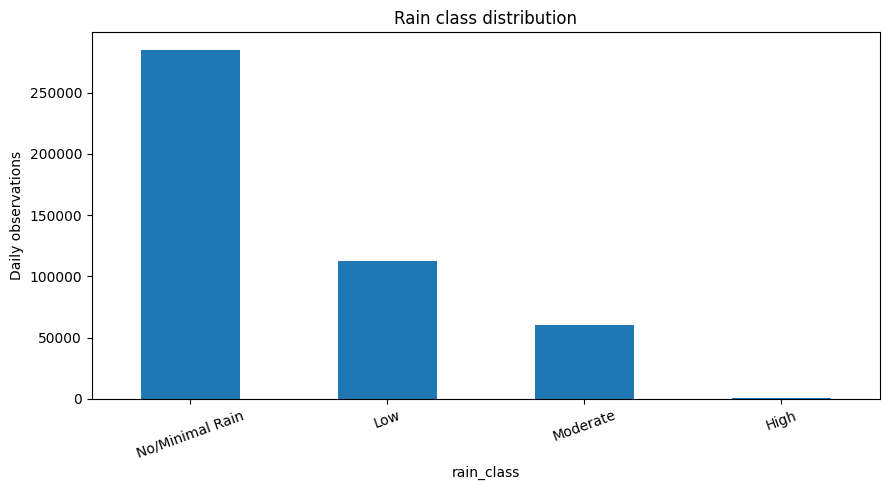

,count,percent
rain_class,,
No/Minimal Rain,285021,62.14
Low,112813,24.60
Moderate,60185,13.12
High,660,0.14


In [17]:
counts=df[T].value_counts().reindex(C,fill_value=0); counts.plot(kind="bar",figsize=(9,5)); plt.title("Rain class distribution"); plt.ylabel("Daily observations"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
display(pd.DataFrame({"count":counts,"percent":(100*counts/counts.sum()).round(2)}))


## Plot 2 — Daily rainfall distribution


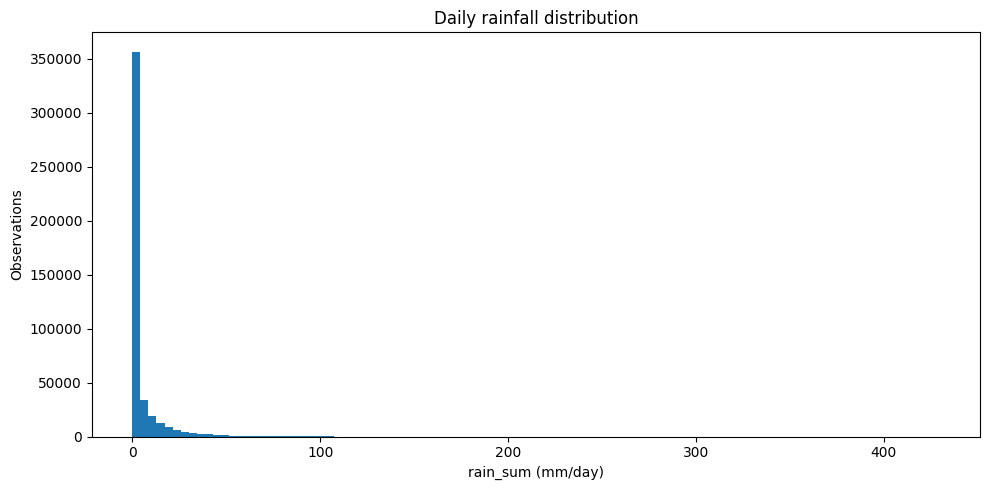

count    458679.000000
mean          4.502095
std          11.327081
min           0.000000
50%           0.200000
75%           3.300000
90%          13.800000
95%          24.400000
99%          54.000000
99.5%        68.500000
99.9%       111.200000
max         429.700000
Name: rain_sum, dtype: float64

In [18]:
plt.figure(figsize=(10,5)); plt.hist(df.rain_sum.dropna(),bins=100); plt.title("Daily rainfall distribution"); plt.xlabel("rain_sum (mm/day)"); plt.ylabel("Observations"); plt.tight_layout(); plt.show()
display(df.rain_sum.describe(percentiles=[.5,.75,.9,.95,.99,.995,.999]))


## Plot 3 — Monthly class distribution


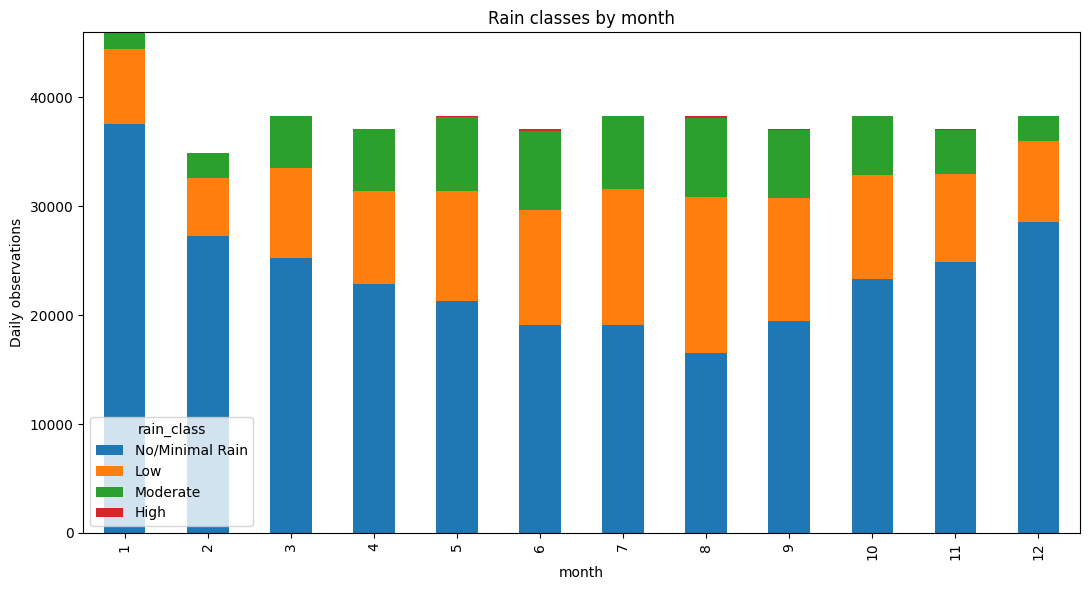

In [19]:
pd.crosstab(df.month,df[T]).reindex(columns=C,fill_value=0).plot(kind="bar",stacked=True,figsize=(11,6)); plt.title("Rain classes by month"); plt.ylabel("Daily observations"); plt.tight_layout(); plt.show()


## Plot 4 — Correlation heatmap


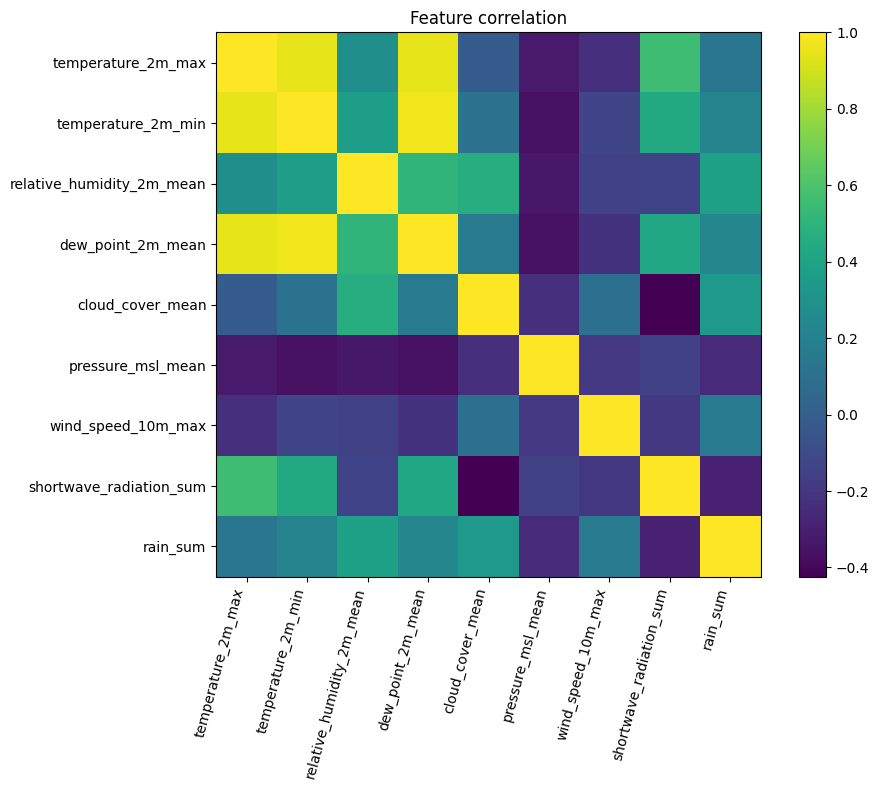

In [20]:
corr=df[F+["rain_sum"]].corr(); fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(corr); ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr))); ax.set_xticklabels(corr.columns,rotation=75,ha="right"); ax.set_yticklabels(corr.columns); fig.colorbar(im,ax=ax); plt.title("Feature correlation"); plt.tight_layout(); plt.show()


## Chronological train/test split

Set `TEST_SIZE` in the first cell. The earliest dates train the model; the latest dates are held out for testing. Rows from the same date stay together, so the actual fraction may differ slightly. Keep the split fixed when comparing feature removal or hyperparameters.


In [21]:
# Chronological train/test split: earliest dates train, latest dates test.
# TEST_SIZE is a fraction of eligible rows, not a percentage of calendar years.
req = F + [T, "date"]
missing = [c for c in req if c not in df]
assert not missing, f"Missing columns: {missing}"
assert F, "At least one predictor must remain after REMOVE_FEATURES"
d = df.dropna(subset=req).sort_values("date", kind="stable").copy()
assert len(d) >= 2, "Need at least two complete rows for train/test split"
cutoff = int(len(d) * (1 - TEST_SIZE))
assert 0 < cutoff < len(d), "TEST_SIZE leaves an empty train or test set"
train, test = d.iloc[:cutoff].copy(), d.iloc[cutoff:].copy()
# Prevent the same date from appearing in both partitions (multiple towns/day).
boundary_date = test["date"].iloc[0]
train = d[d["date"] < boundary_date].copy()
test = d[d["date"] >= boundary_date].copy()
assert len(train) and len(test), "Not enough distinct dates to make a chronological split"
Xtr, ytr = train[F], train[T]
Xte, yte = test[F], test[T]
train.to_csv(M / "training.csv", index=False)
test.to_csv(M / "testing.csv", index=False)
print(f"Requested test fraction: {TEST_SIZE:.0%}")
print(f"Actual row fraction: train={len(train)/len(d):.1%}, test={len(test)/len(d):.1%}")
print("Train:", len(train), train.date.min(), "to", train.date.max())
print("Test: ", len(test), test.date.min(), "to", test.date.max())
display(pd.DataFrame({"train": ytr.value_counts().reindex(C, fill_value=0),
                      "test": yte.value_counts().reindex(C, fill_value=0)}))


Requested test fraction: 20%
Actual row fraction: train=80.0%, test=20.0%
Train: 343035 2021-01-01 00:00:00 to 2025-01-24 00:00:00
Test:  85932 2025-01-25 00:00:00 to 2026-01-31 00:00:00


,train,test
rain_class,,
No/Minimal Rain,213433,53314
Low,83485,22455
Moderate,45572,10111
High,545,52


## Train four classifiers


In [22]:
models={"Gradient Boosting":GradientBoostingClassifier(random_state=RANDOM_STATE),"Random Forest":RandomForestClassifier(n_estimators=300,random_state=RANDOM_STATE,n_jobs=-1,class_weight="balanced"),"CART":DecisionTreeClassifier(random_state=RANDOM_STATE,class_weight="balanced")}
rows=[]; preds={}
for name,m in models.items():
 if name in MODEL_PARAM_OVERRIDES: m.set_params(**MODEL_PARAM_OVERRIDES[name])
 print("Training",name); m.fit(Xtr,ytr); p=m.predict(Xte); preds[name]=p
 rows.append({"Model":name,"Accuracy":accuracy_score(yte,p),"Macro Precision":precision_score(yte,p,average="macro",zero_division=0),"Macro Recall":recall_score(yte,p,average="macro",zero_division=0),"Macro F1":f1_score(yte,p,average="macro",zero_division=0)})
results=pd.DataFrame(rows).sort_values("Macro F1",ascending=False); display(results)


Training Gradient Boosting
Training Random Forest
Training CART


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.743367,0.630236,0.475598,0.498684
0,Gradient Boosting,0.741528,0.516999,0.469403,0.486241
2,CART,0.668598,0.429814,0.426598,0.427963


## Detailed reports and confusion matrices



 Gradient Boosting
                 precision    recall  f1-score   support

No/Minimal Rain       0.81      0.91      0.86     53314
            Low       0.55      0.44      0.49     22455
       Moderate       0.65      0.50      0.57     10111
           High       0.06      0.02      0.03        52

       accuracy                           0.74     85932
      macro avg       0.52      0.47      0.49     85932
   weighted avg       0.72      0.74      0.73     85932



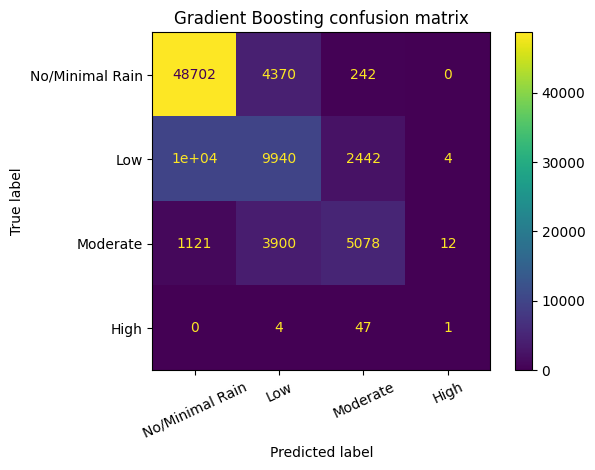


 Random Forest
                 precision    recall  f1-score   support

No/Minimal Rain       0.81      0.92      0.86     53314
            Low       0.55      0.44      0.49     22455
       Moderate       0.66      0.51      0.57     10111
           High       0.50      0.04      0.07        52

       accuracy                           0.74     85932
      macro avg       0.63      0.48      0.50     85932
   weighted avg       0.73      0.74      0.73     85932



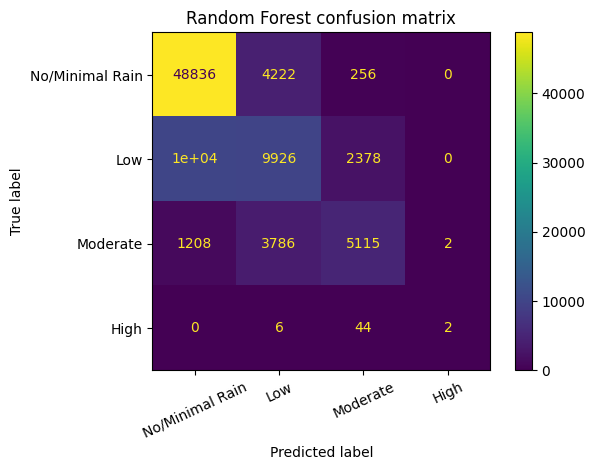


 CART
                 precision    recall  f1-score   support

No/Minimal Rain       0.79      0.82      0.81     53314
            Low       0.43      0.40      0.41     22455
       Moderate       0.47      0.47      0.47     10111
           High       0.02      0.02      0.02        52

       accuracy                           0.67     85932
      macro avg       0.43      0.43      0.43     85932
   weighted avg       0.66      0.67      0.66     85932



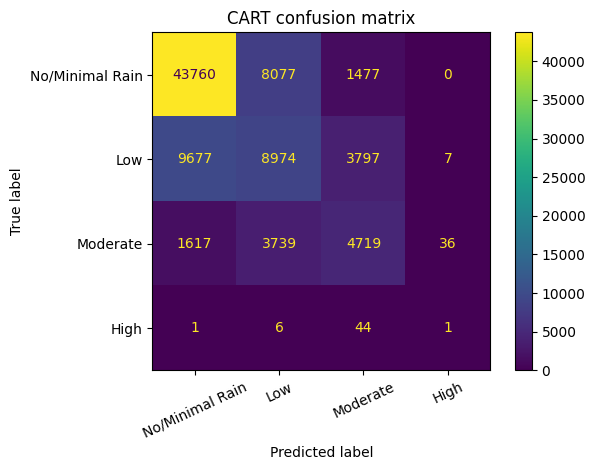

In [23]:
for name,p in preds.items():
 print("\n",name); print(classification_report(yte,p,labels=C,zero_division=0))
 ConfusionMatrixDisplay.from_predictions(yte,p,labels=C,xticks_rotation=25); plt.title(name+" confusion matrix"); plt.tight_layout(); plt.show()


## Feature importance


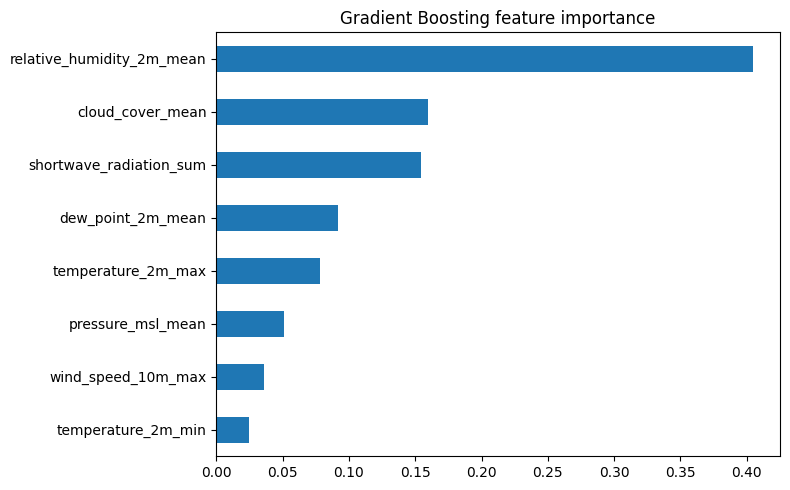

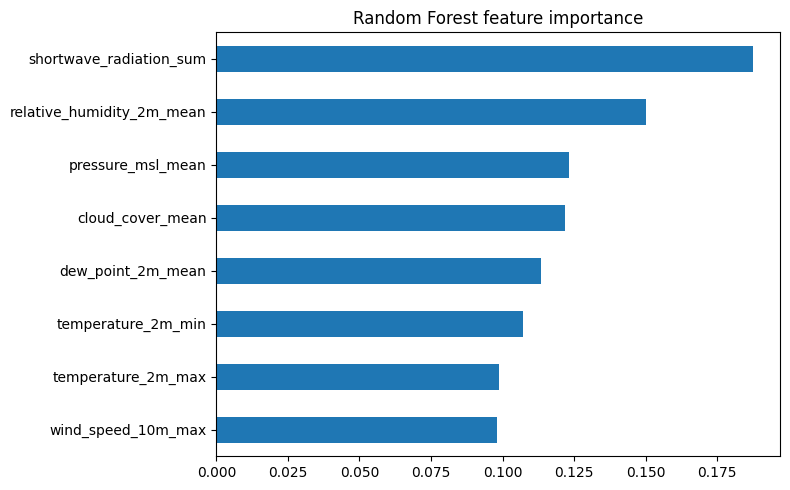

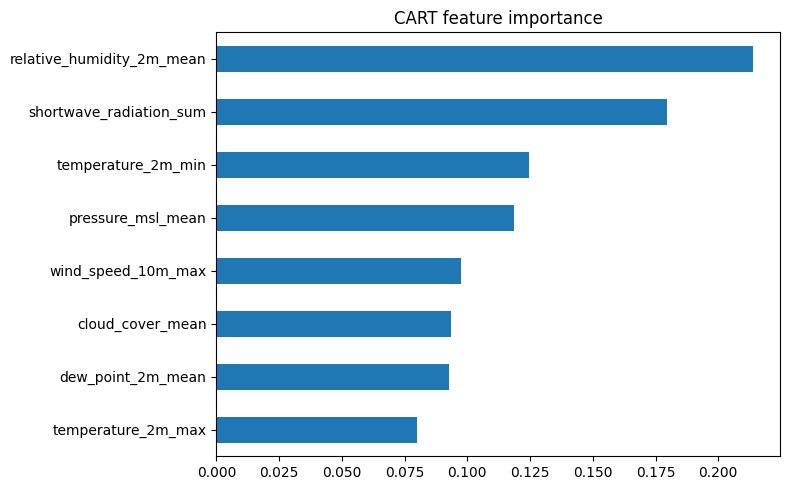

In [24]:
for name in ["Gradient Boosting","Random Forest","CART"]:
 pd.Series(models[name].feature_importances_,index=F).sort_values().plot(kind="barh",figsize=(8,5)); plt.title(name+" feature importance"); plt.tight_layout(); plt.show()


## Save models and results


In [25]:
names={"Gradient Boosting":"gradient_boosting.joblib","Random Forest":"random_forest.joblib","CART":"cart.joblib"}
for n,m in models.items(): joblib.dump(m,M/names[n]); print("Saved",M/names[n])
results.to_csv(M/"model_results.csv",index=False); print("Done:",M)


Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\gradient_boosting.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\random_forest.joblib
Saved c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models\cart.joblib
Done: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\trained_models


## Experiment log (run after training)

The CSV and JSON are intended for reporting. This cell does **not** retrain or tune anything. Record the score table above and compare it with earlier runs. Review data leakage and validation methodology before claiming improvements.


In [ ]:
from pathlib import Path
import json, datetime
import pandas as pd
experiment_root = Path.cwd() / "experiment_logs" / EXPERIMENT_ID
experiment_root.mkdir(parents=True, exist_ok=True)
active_features = globals().get("FEATURES", globals().get("feature_columns", globals().get("F", [])))
metadata = {"experiment_id": EXPERIMENT_ID, "notebook": "train_rain_models", "created_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
 "features": list(active_features), "removed": REMOVE_FEATURES, "test_size_requested": TEST_SIZE, "random_state": RANDOM_STATE,
 "train_rows": len(train), "test_rows": len(test), "train_end": str(train.date.max()), "test_start": str(test.date.min()), 
 "model_overrides": MODEL_PARAM_OVERRIDES,
 "note": "Test metrics are descriptive; tune using validation data, not test data."}
(experiment_root / "experiment_config.json").write_text(json.dumps(metadata, indent=2, default=str), encoding="utf-8")
for key in ("results_df", "results"):
    obj = globals().get(key)
    if isinstance(obj, pd.DataFrame):
        obj.to_csv(experiment_root / "model_comparison.csv", index=False)
        display(obj)
        break
else:
    print("No tabular model comparison found; refer to evaluation outputs above.")
print("Experiment saved to:", experiment_root)
print("Report checklist: model | features | parameter changes | split | validation metric | test metric | training time | interpretation")


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Random Forest,0.743367,0.630236,0.475598,0.498684
0,Gradient Boosting,0.741528,0.516999,0.469403,0.486241
2,CART,0.668598,0.429814,0.426598,0.427963


Experiment saved to: c:\Users\IAN\Desktop\SEM (SWIN)\SEM 2\COS30049-Computing Technology Innovation Project\Assignments\Dev\Rain\experiment_logs\remove_month_v1
Report checklist: model | features | parameter changes | split | validation metric | test metric | training time | interpretation
